# インド株 ファクター検証 — Step 3: 中立化バリアント（サイズ / セクター / 両方）

Step 1（分位分析）・Step 2（IC）を、**中立化の有無**で並べて比較する。

| バリアント | 落とすもの | 問い |
|---|---|---|
| `none` | — | 素のシグナル |
| `size` | $\log \text{Cap}$ | 効果はサイズ（小型株プレミアム）由来か？ |
| `sector` | GICS セクターダミー | 効果はセクター配分由来か？ |
| `size_sector` | 両方（1本の回帰で同時） | セクター内・同規模で比べても残るか？ |

## 中立化の定義（`docs/tutorial/02` 2.5）

標準化済みスコア $z_{i,t}$ を、時点 $t$ のクロスセクション回帰にかけた**残差**を使う:

$$z_{i,t} = \gamma_0 + \sum_g \gamma_g\,\mathbb{1}[i \in g] + \gamma_s \log \text{Cap}_{i,t} + \varepsilon_{i,t},
\qquad x_{i,t} = \frac{\varepsilon_{i,t}}{\sigma(\varepsilon_{\cdot,t})}$$

### セクター中立の具体形

セクターは **GICS 上2桁の 11 個のダミー変数**で表現し、被説明変数をスコア、
説明変数をダミー（＋サイズ）とする**クロスセクション回帰の残差**を新しいスコアとする。
「各セクターの平均スコアを 0 にする」操作と等価で、
`sector` 単独なら「セクター内 demean してから全体を標準化」と同じになる。

実装上の注意:

- 計画行列は `[11 セクターダミー | log_cap | 定数項]`。ダミーを全部入れたうえで
  定数項も置いているため**設計上は共線**（rank 12 < 13）。`np.linalg.lstsq` の
  最小ノルム解を使っており、**残差はダミーを1本落とした教科書型の回帰と厳密に一致する**
  （係数の解釈はしないので問題にならない。ノート内で数値確認済み）
- セクター分類はその月の `universe/{t}.pkl` の `gics` を使う。
  分類変更が遡及適用されないので、時点 $t$ 当時の分類になっている
- 回帰は**毎月そのクロスセクションだけ**で推定（全期間プールは不可）
- `size_sector` は「サイズを落としてからセクターを落とす」逐次ではなく、
  **1本の回帰で同時に**落とす（逐次だと落とす順序に結果が依存するため）
- サイズは $\log$(浮動株調整後時価総額 USD)。本データでは `log_cap` / `sector` とも
  欠損ゼロなので、中立化でユニバースが痩せることはない

なお `size` 中立化は「ユニバースを小型株に偏らせない」ためのもので、
ベンチマーク（MSCI India = 大型・中型）との対比とは別の話。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 220, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

# ---- 設定 --------------------------------------------------------------------
FACTOR = "mom12_1"                  # Step 2 で最も明確だったモメンタムを主対象に
FACTOR_LABEL = "Momentum (mom12_1)"
METHOD = "blom"
START, END = 200701, 202607
N_QUANTILE = 5
HORIZONS = list(range(1, 13))
VARIANTS = ["none", "size", "sector", "size_sector"]
LABELS = fl.preprocess.VARIANT_LABEL

## 1. 4 バリアントのスコアを作る

`make_neutral_variants` が「Blom 標準化 → 指定した中立化回帰の残差」を
バリアントごとに列として追加し、`{variant: 列名}` の辞書を返す。

In [2]:
panel = fl.data.build_panel([FACTOR], start=START, end=END)
panel, score_cols = fl.preprocess.make_neutral_variants(panel, FACTOR, method=METHOD, variants=VARIANTS)
panel = fl.data.add_forward_returns(panel, HORIZONS)

print(score_cols)
panel[[FACTOR, "log_cap", "sector"] + list(score_cols.values())].head()

{'none': 'mom12_1_blom', 'size': 'mom12_1_blom_size', 'sector': 'mom12_1_blom_sector', 'size_sector': 'mom12_1_blom_size_sector'}


mom12_1  log_cap sector  mom12_1_blom  mom12_1_blom_size  mom12_1_blom_sector  mom12_1_blom_size_sector
yyyymm bid                                                                                                             
200701 INDAAC1  23.3434   7.5525     25       -0.2470            -0.1659              -0.0621                   -0.0783
       INDAAT1  93.8383   7.7200     15        1.4704             1.6354               1.1972                    1.2794
       INDAAV1   7.0854   7.5715     15       -0.8158            -0.7641              -1.5630                   -1.6912
       INDAAW1  13.5553   8.1999     30       -0.6860            -0.6413              -0.6806                   -0.2801
       INDAAY1  15.4238   8.3676     30       -0.5670            -0.5197              -0.5369                   -0.1314

In [3]:
# セクター構成（GICS 上2桁）と月次のセクター数
print("sectors:", sorted(panel["sector"].unique()))
print("銘柄数/月 の中央値:", int(panel.groupby(level="yyyymm").size().median()))
panel.groupby("sector").size().to_frame("n_obs").T

sectors: ['10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60']
銘柄数/月 の中央値: 329


sector,10,15,20,25,30,35,40,45,50,55,60
n_obs,2422,13867,15156,13578,5435,7822,13920,6115,2090,3547,1541


### 中立化が効いているかの確認

- `corr_log_cap` — スコアと $\log$Cap の月次相関の平均。**サイズ中立なら ≈ 0**
- `sector_disp` — セクター平均スコアの月次標準偏差の平均。**セクター中立なら ≈ 0**
- `corr_with_none` — 素のスコアとの相関。低いほど「落とした情報が多い」

In [4]:
fl.preprocess.neutralization_check(panel, score_cols)

,corr_log_cap,sector_disp,corr_with_none
none,0.1552,0.4160,1.0000
size,0.0000,0.4179,0.9777
sector,0.1510,0.0000,0.9359
size_sector,0.0000,0.0000,0.9152


## 2. 分位分析の比較

各バリアントのスコアで独立に 5 分位に分割し（Q5 = 最上位）、
Step 1 と同じ EW / CW の超過リターンを計算する。

In [5]:
res, summaries_ew, summaries_cw = {}, {}, {}
for v, col in score_cols.items():
    res[v] = fl.quantile.quantile_returns(panel, col, q=N_QUANTILE, ascending=True)
    summaries_ew[v] = fl.quantile.quantile_summary(res[v], weighting="ew")
    summaries_cw[v] = fl.quantile.quantile_summary(res[v], weighting="cw")

spread = f"Q{N_QUANTILE}-Q1"
pd.concat(
    {LABELS[v]: pd.DataFrame({
        "EW": summaries_ew[v].loc[spread],
        "CW": summaries_cw[v].loc[spread],
    }).T for v in VARIANTS},
    names=["neutralization", "weighting"],
)[["ann_excess", "ann_excess_arith", "ann_vol", "te", "IR", "t_stat_NW", "hit_ratio"]]

ann_excess  ann_excess_arith  ann_vol     te     IR  t_stat_NW  hit_ratio
neutralization        weighting                                                                           
No neutralization     EW             0.0803            0.1113   0.2383 0.2383 0.4673     1.9741     0.6197
                      CW            -0.0321            0.0191   0.2978 0.2978 0.0640     0.2874     0.5427
Size-neutral          EW             0.0754            0.1009   0.2217 0.2217 0.4551     1.9054     0.5897
                      CW            -0.0162            0.0203   0.2593 0.2593 0.0783     0.3316     0.5470
Sector-neutral        EW             0.0833            0.1078   0.2149 0.2149 0.5017     2.1456     0.6239
                      CW             0.0181            0.0510   0.2433 0.2433 0.2098     0.9403     0.5598
Size + sector neutral EW             0.0917            0.1093   0.1958 0.1958 0.5580     2.4045     0.6154
                      CW             0.0426            0.0683   0.2250 0.2250 0.3037     1.2108     0.5556

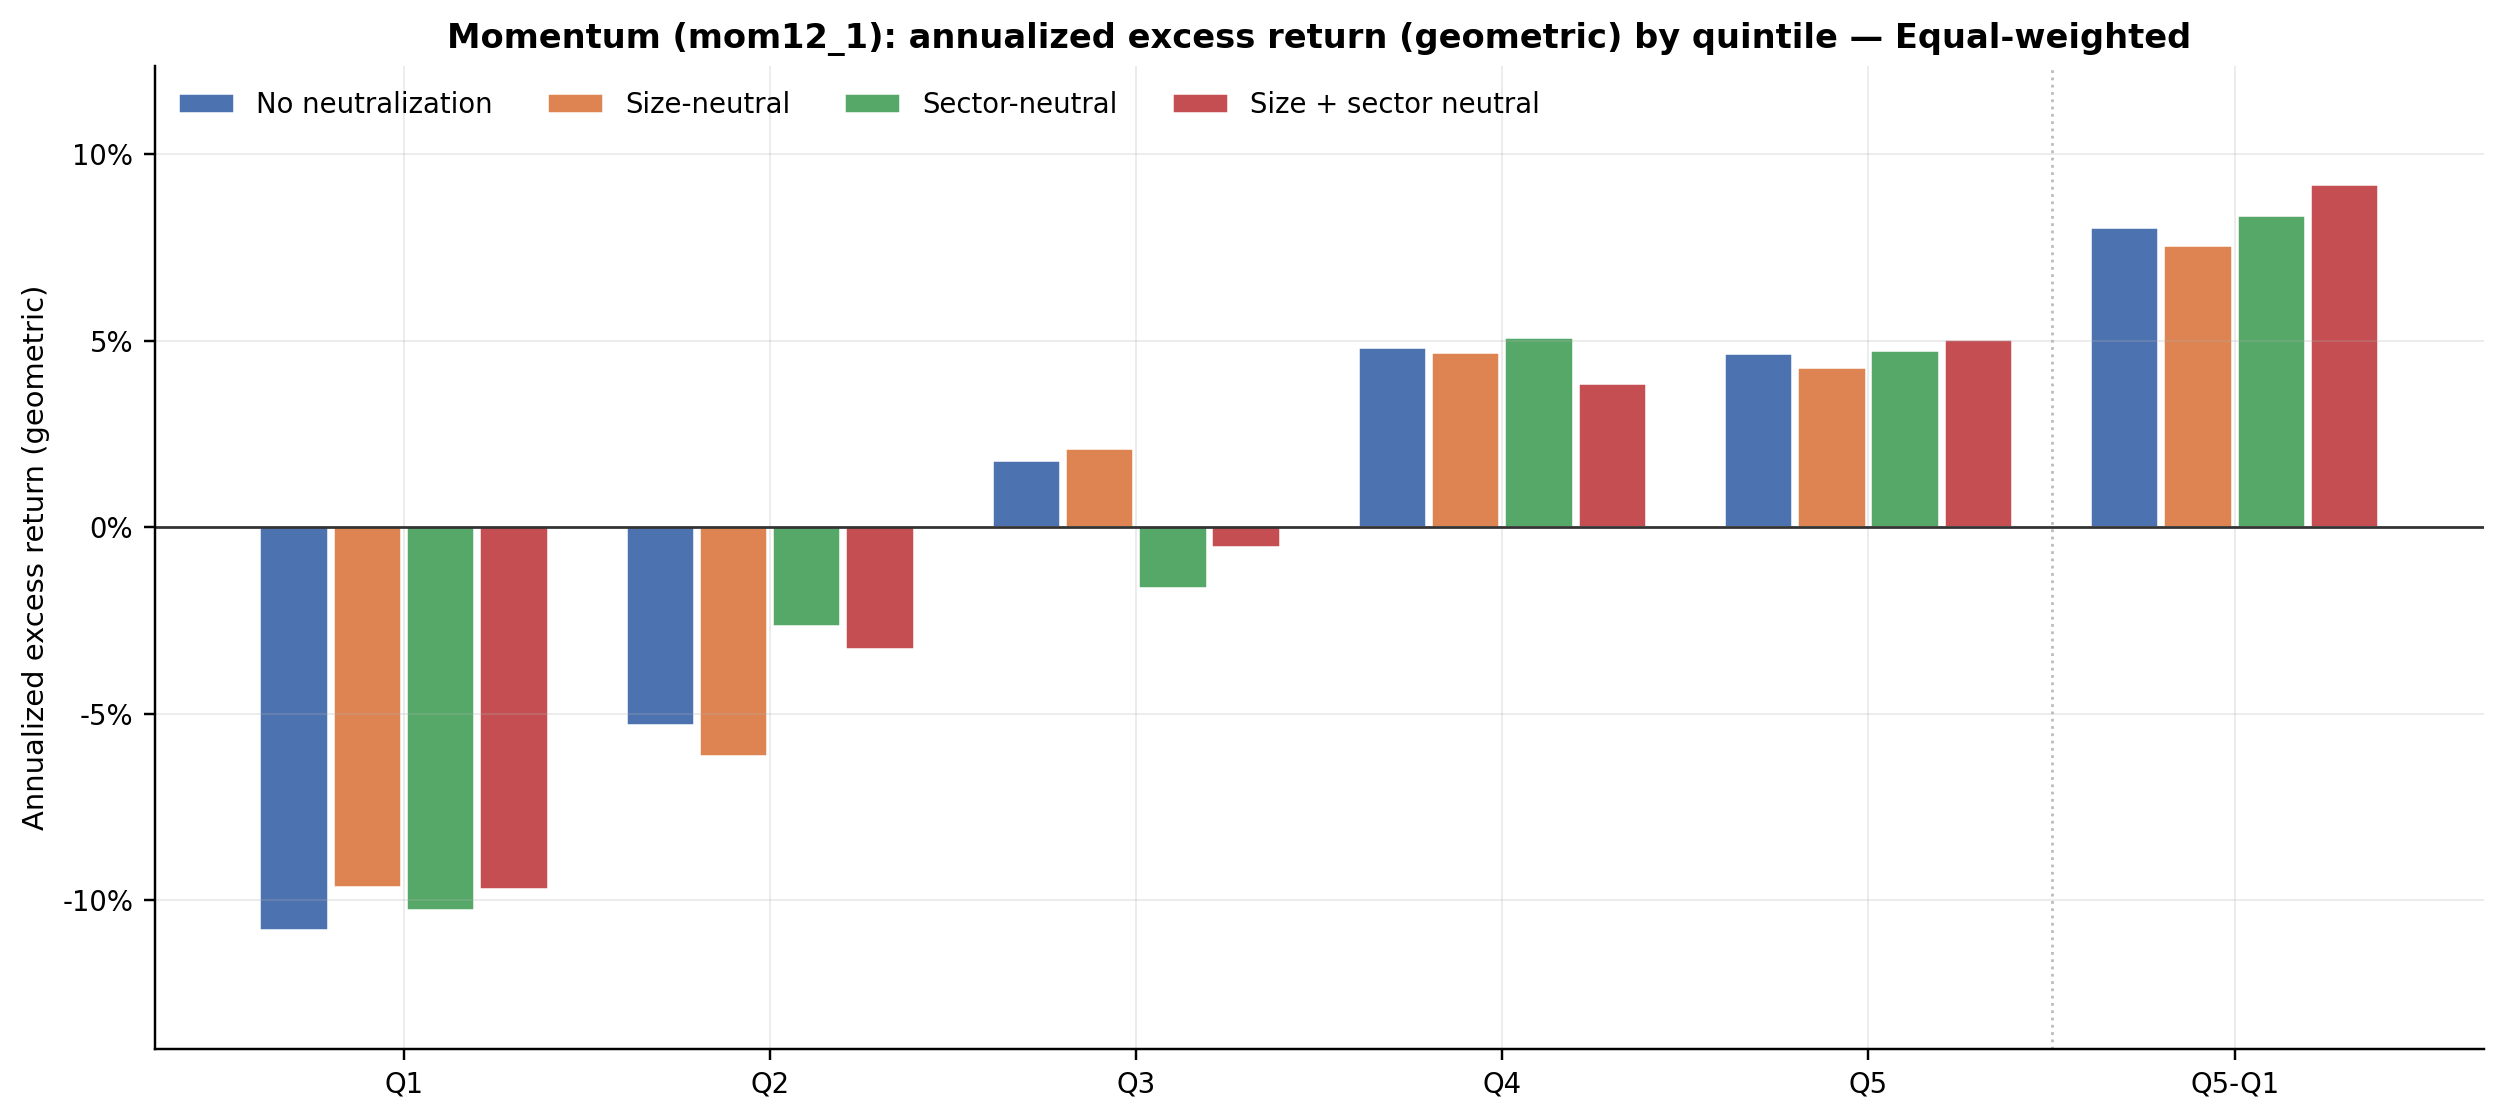

In [6]:
fig = fl.plotting.plot_variant_quantile_bar(summaries_ew, q=N_QUANTILE, factor=FACTOR_LABEL,
                                            weighting="ew", labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/20_variant_quantile_ew");

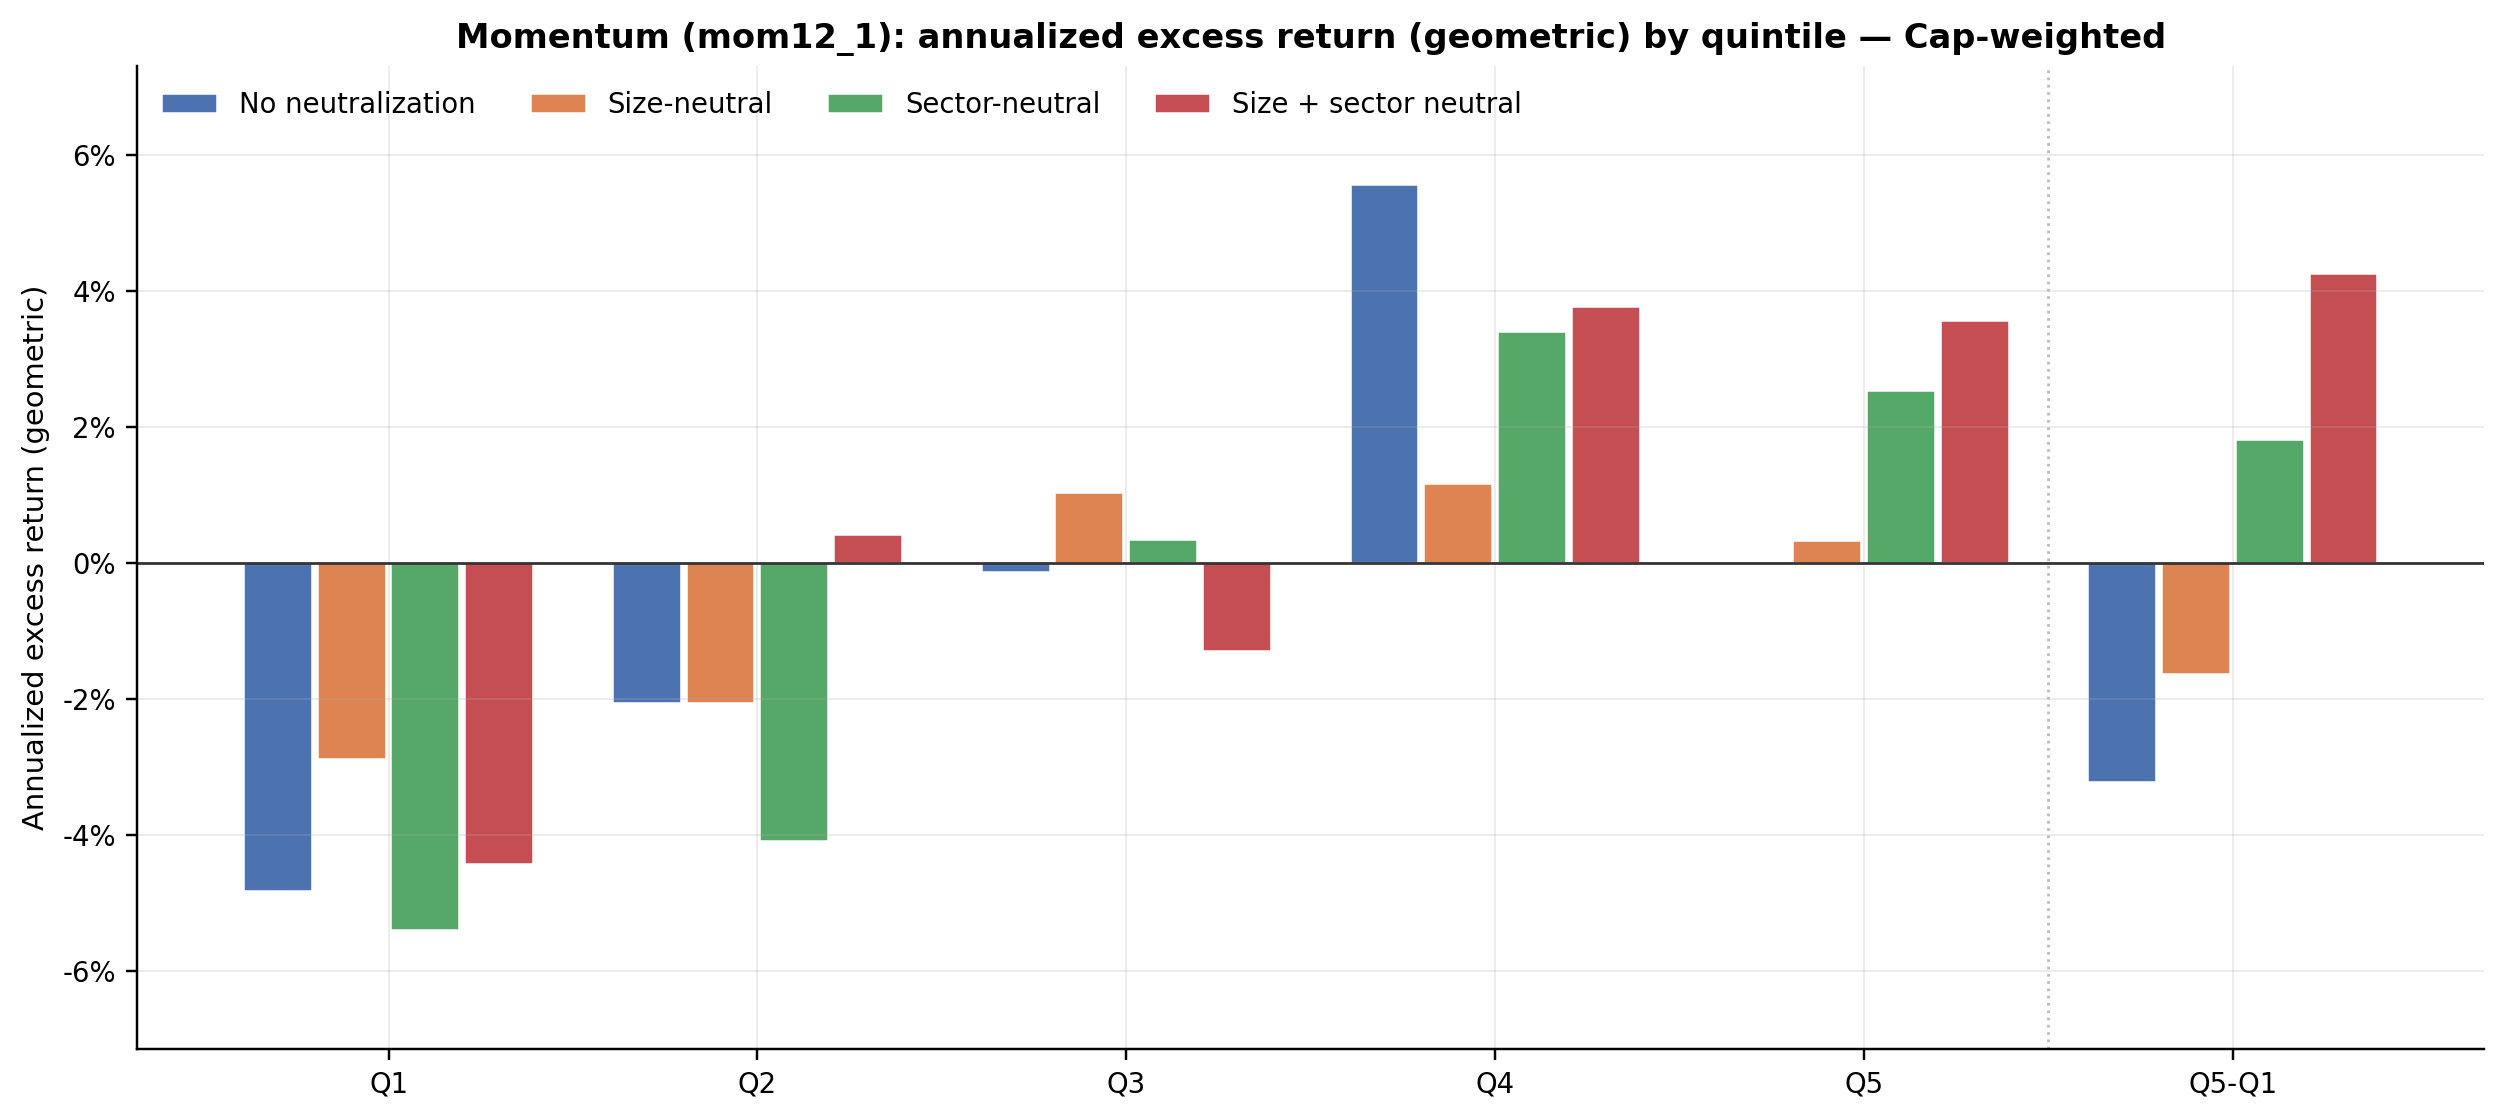

In [7]:
fig = fl.plotting.plot_variant_quantile_bar(summaries_cw, q=N_QUANTILE, factor=FACTOR_LABEL,
                                            weighting="cw", labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/21_variant_quantile_cw");

## 3. IC の比較

同じ 4 バリアントで IC 時系列と減衰を比較する。

In [8]:
ics, decays = {}, {}
for v, col in score_cols.items():
    ics[v] = fl.ic.information_coefficient(panel, col, "fwd_rtn", method="spearman")
    _, decays[v] = fl.ic.ic_decay(panel, col, horizons=HORIZONS, method="spearman")

pd.DataFrame({LABELS[v]: fl.ic.ic_summary(ics[v]) for v in VARIANTS}).T

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
No neutralization,234.0000,0.0550,0.1826,0.3009,1.0425,4.6034,4.5621,0.6368,0.0035
Size-neutral,234.0000,0.0504,0.1716,0.2937,1.0173,4.4922,4.5296,0.6368,0.0044
Sector-neutral,234.0000,0.0509,0.1576,0.3230,1.1188,4.9405,4.9690,0.6496,-0.0155
Size + sector neutral,234.0000,0.0461,0.1465,0.3149,1.0910,4.8178,4.9416,0.6453,-0.0141


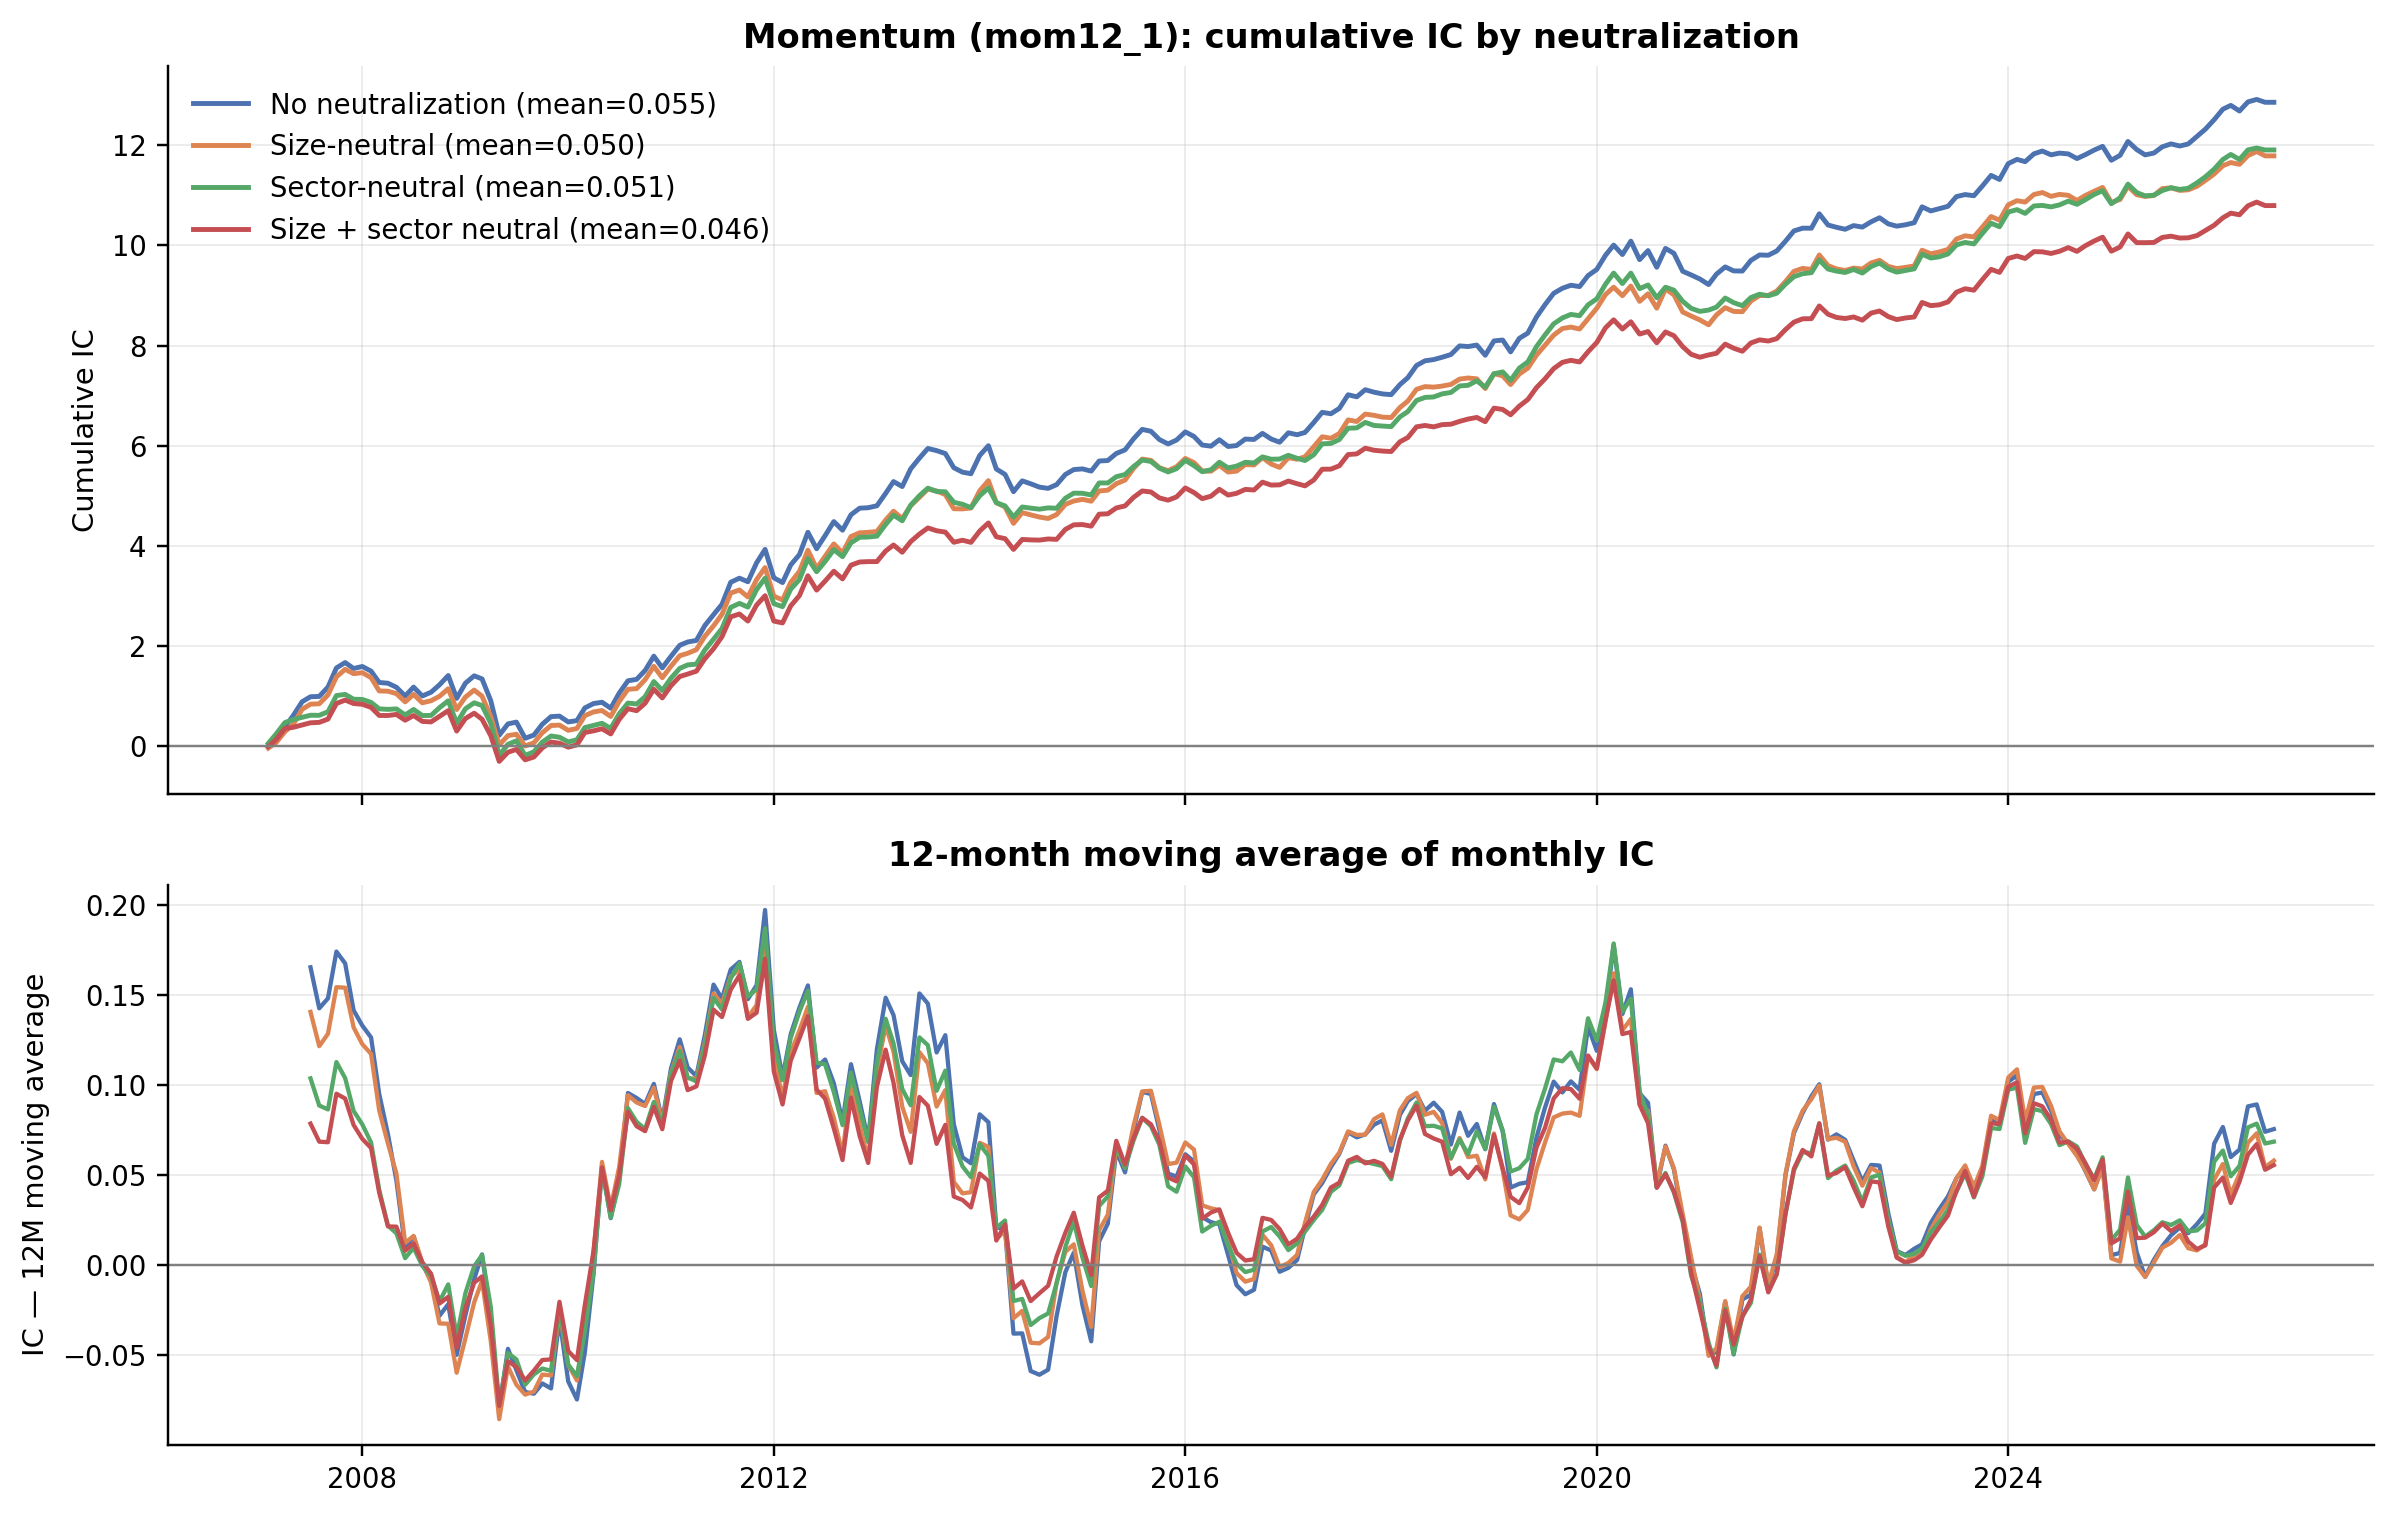

In [9]:
fig = fl.plotting.plot_cumulative_ic_compare(ics, factor=FACTOR_LABEL, labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/22_variant_cumulative_ic");

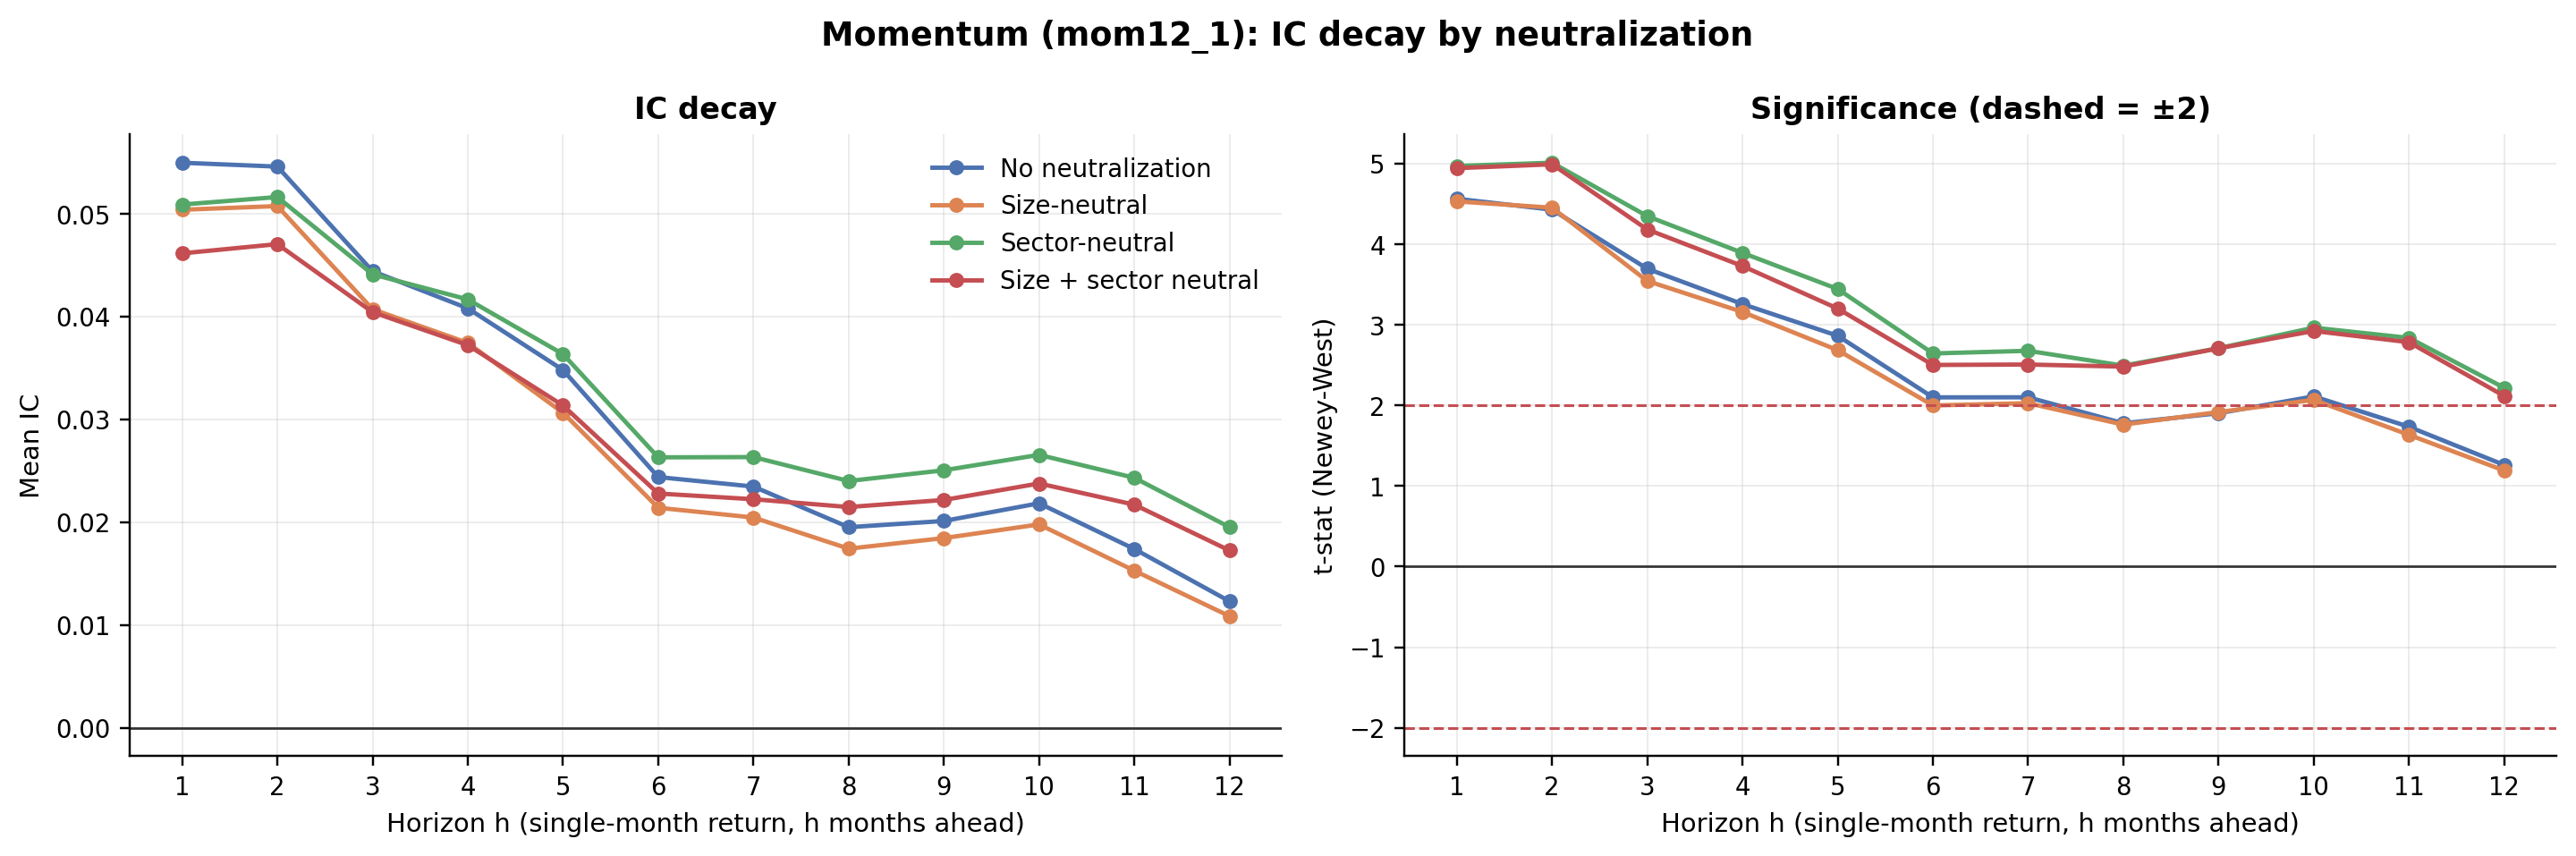

In [10]:
fig = fl.plotting.plot_ic_decay_compare(decays, factor=FACTOR_LABEL, labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/23_variant_ic_decay");

## 4. B/P でも同じ比較

Step 1・2 で弱かった B/P について、中立化で見え方が変わるかを確認する。

In [11]:
def run_variants(factor: str, method: str = METHOD, variants=VARIANTS, q: int = N_QUANTILE,
                 horizons=HORIZONS, start: int = START, end: int = END):
    # ファクター名だけで 中立化4バリアント x (分位分析, IC) を一括実行
    p = fl.data.build_panel([factor], start=start, end=end)
    p, cols = fl.preprocess.make_neutral_variants(p, factor, method=method, variants=variants)
    p = fl.data.add_forward_returns(p, horizons)
    out = {"panel": p, "score_cols": cols, "res": {}, "ew": {}, "cw": {}, "ic": {}, "decay": {}}
    for v, col in cols.items():
        r = fl.quantile.quantile_returns(p, col, q=q, ascending=True)
        out["res"][v] = r
        out["ew"][v] = fl.quantile.quantile_summary(r, weighting="ew")
        out["cw"][v] = fl.quantile.quantile_summary(r, weighting="cw")
        out["ic"][v] = fl.ic.information_coefficient(p, col, "fwd_rtn", method="spearman")
        _, out["decay"][v] = fl.ic.ic_decay(p, col, horizons=horizons, method="spearman")
    return out


bp = run_variants("bp_act")
pd.DataFrame({LABELS[v]: fl.ic.ic_summary(bp["ic"][v]) for v in VARIANTS}).T

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
No neutralization,234.0000,-0.0168,0.1847,-0.0908,-0.3144,-1.3885,-1.3158,0.4316,0.0597
Size-neutral,234.0000,-0.0126,0.1740,-0.0727,-0.2518,-1.1119,-1.0624,0.4487,0.0733
Sector-neutral,234.0000,-0.0200,0.1598,-0.1253,-0.4342,-1.9173,-1.7309,0.4402,0.0733
Size + sector neutral,234.0000,-0.0146,0.1471,-0.0990,-0.3431,-1.5150,-1.3555,0.4658,0.1060


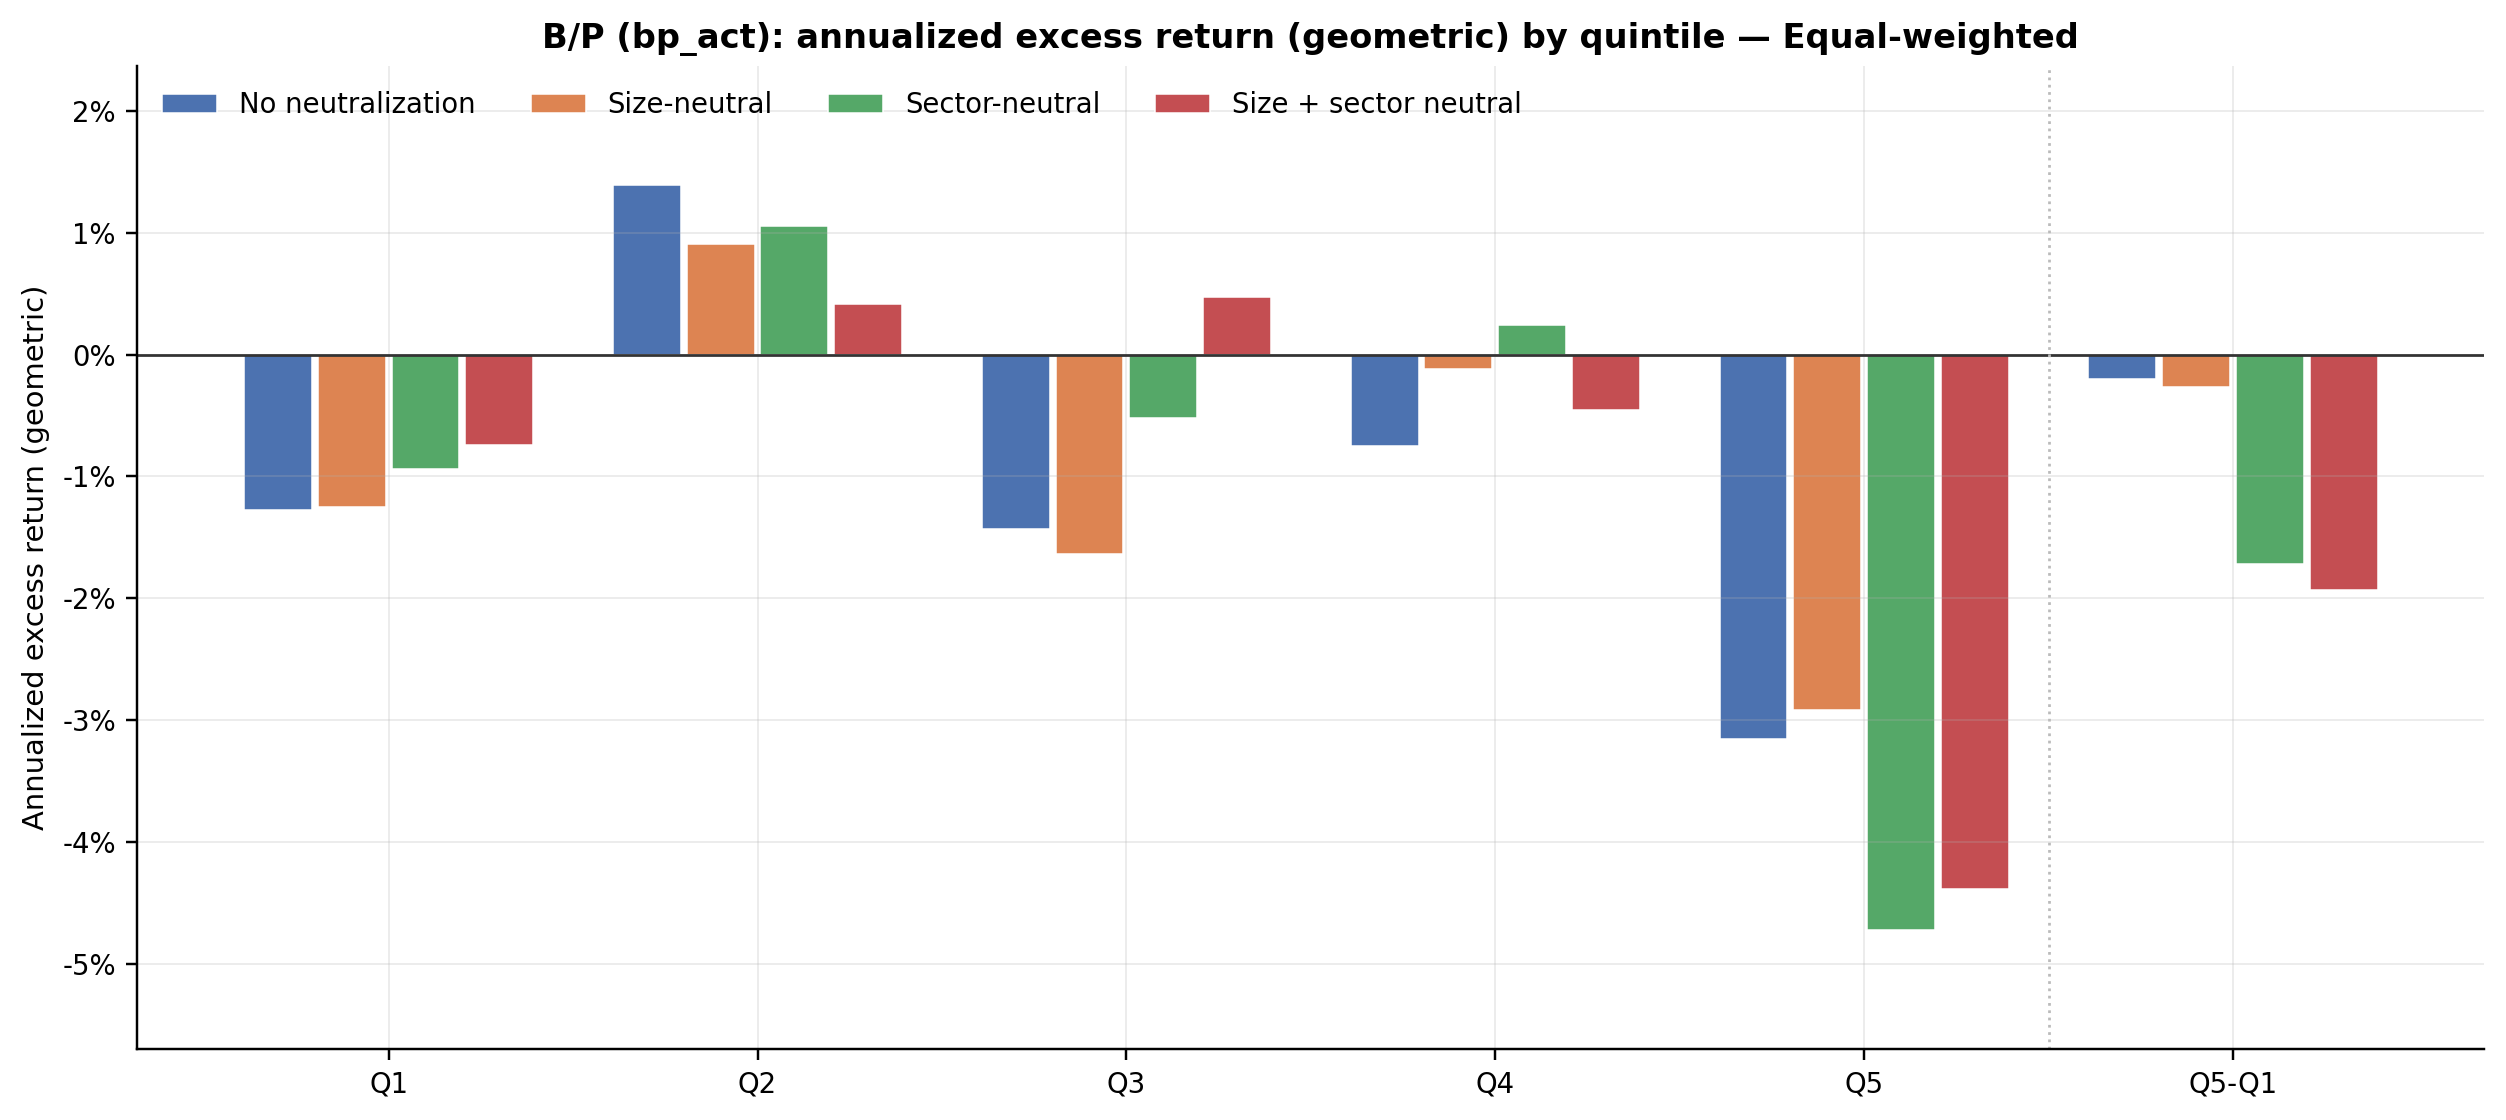

In [12]:
fig = fl.plotting.plot_variant_quantile_bar(bp["ew"], q=N_QUANTILE, factor="B/P (bp_act)",
                                            weighting="ew", labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/24_variant_quantile_ew_bp");

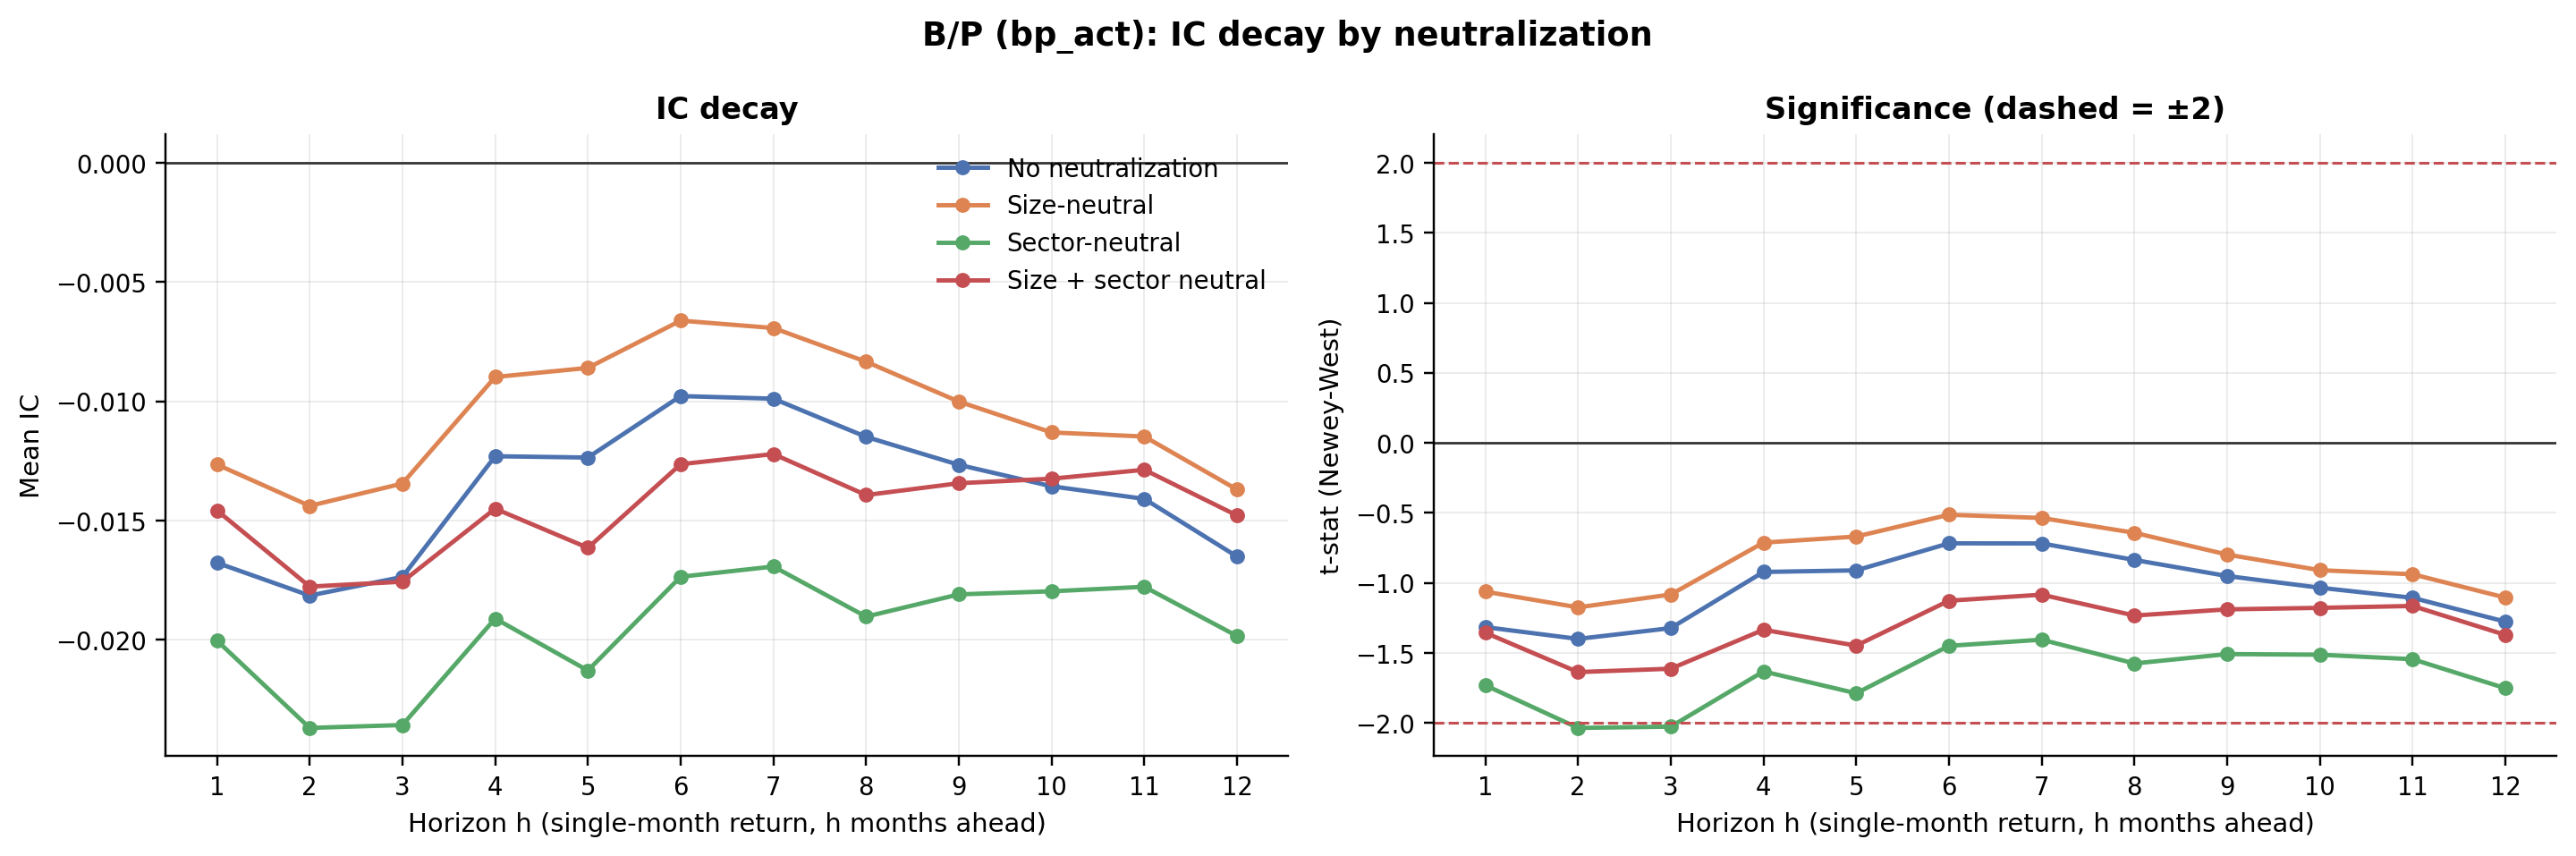

In [13]:
fig = fl.plotting.plot_ic_decay_compare(bp["decay"], factor="B/P (bp_act)", labels=LABELS)
fl.plotting.savefig(fig, "03_neutralization/25_variant_ic_decay_bp");

---

## 次のステップ

**ファクターリターン**: 翌月リターンをファクター1本に回帰した傾き $f_t$ の累積

$$r_{i,t \to t+1} = a_t + f_t\, x_{i,t} + u_{i,t}$$

実装は `src/factorlab/regression.py`（`factor_return` / `factor_return_summary`）に用意済み。
中立化バリアントごとに $f_t$ を出せば、本ノートと同じ4本並びで比較できる。